DATA DIAGNOSTIC
Found 13507 images belonging to 32 classes.
Found 3359 images belonging to 32 classes.
Found 4382 images belonging to 32 classes.
✓ Number of classes: 32
✓ Class names: {'Apple_Scab_Leaf': 0, 'Apple_leaf': 1, 'Apple_rust_leaf': 2, 'Blueberry_leaf': 3, 'Cherry_leaf': 4, 'Corn_Gray_leaf_spot': 5, 'Corn_leaf_blight': 6, 'Corn_rust_leaf': 7, 'Peach_leaf': 8, 'Pepper__bell___Bacterial_spot': 9, 'Pepper__bell___healthy': 10, 'Potato___healthy': 11, 'Potato_leaf_early_blight': 12, 'Potato_leaf_late_blight': 13, 'Raspberry_leaf': 14, 'Soyabean_leaf': 15, 'Squash_Powdery_mildew_leaf': 16, 'Strawberry_leaf': 17, 'Tomato_Bacterial_spot': 18, 'Tomato_Early_blight': 19, 'Tomato_Late_blight': 20, 'Tomato_Leaf_Mold': 21, 'Tomato_Septoria_leaf_spot': 22, 'Tomato__Target_Spot': 23, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 24, 'Tomato_healthy': 25, 'Tomato_leaf': 26, 'Tomato_leaf_mosaic_virus': 27, 'Tomato_leaf_yellow_virus': 28, 'Tomato_two_spotted_spider_mites_leaf': 29, 'grape_leaf': 

✓ Test Loss: 0.1655
✓ Test Accuracy: 0.9642
✓ Model saved successfully!


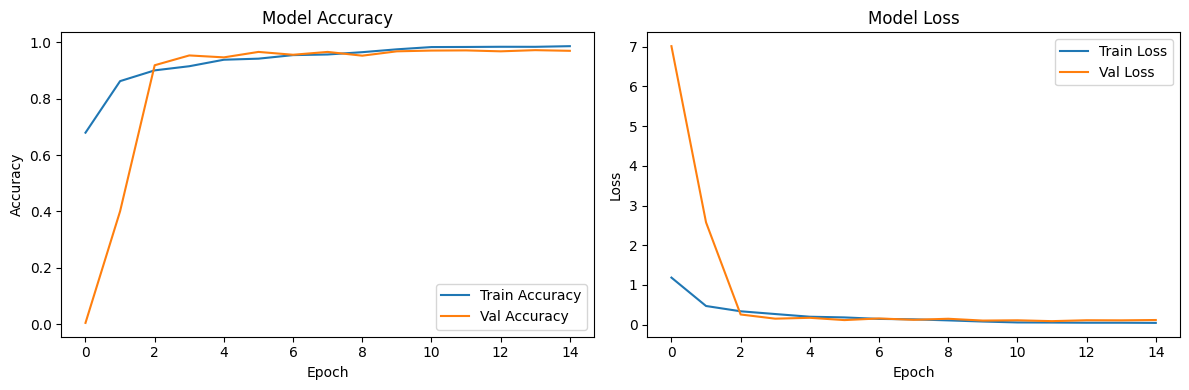

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Fixed: Use only train and test folders (no val)
train_dir = "combined_dataset/train"
test_dir = "combined_dataset/test"

# DIAGNOSTIC: Check your data first
print("=" * 50)
print("DATA DIAGNOSTIC")
print("=" * 50)

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    brightness_range=[0.9, 1.1],
    validation_split=0.2
)

# No augmentation for test
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Load validation data
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Load test data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Print diagnostic info
print(f"✓ Number of classes: {train_generator.num_classes}")
print(f"✓ Class names: {train_generator.class_indices}")
print(f"✓ Training samples: {train_generator.samples}")
print(f"✓ Validation samples: {val_generator.samples}")
print(f"✓ Test samples: {test_generator.samples}")
print("=" * 50)

# Visualize sample batch
sample_batch, sample_labels = next(iter(train_generator))
print(f"✓ Sample batch shape: {sample_batch.shape}")
print(f"✓ Label shape: {sample_labels.shape}")

# Load pretrained ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# CRITICAL FIX: Unfreeze all layers from the start
for layer in base_model.layers:
    layer.trainable = True

# Build improved model with batch normalization
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.3)(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.00005),  # Much lower learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "=" * 50)
print("TRAINING STAGE 1: All layers trainable")
print("=" * 50)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-8,
    verbose=1
)

# Train all layers
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate on test set
print("\n" + "=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"✓ Test Loss: {test_loss:.4f}")
print(f"✓ Test Accuracy: {test_acc:.4f}")

# Save model
model.save("plant_disease_resnet_model.h5")
print("✓ Model saved successfully!")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Train Accuracy')
plt.plot(history1.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('training_history.png')
plt.show()